In [ ]:
#역행렬 계산
import numpy as np
A=np.array([[1,3,5],[2,5,1],[2,3,8]])
Ainv=np.linalg.inv(A)
print(Ainv)


[[-1.48  0.36  0.88]
 [ 0.56  0.08 -0.36]
 [ 0.16 -0.12  0.04]]


In [1]:
#행렬
import numpy as np
from scipy import linalg

n=500
Q=linalg.orth(np.random.randn(n,n))
D=np.linspace(0,-10,n)
A=Q.dot(np.diag(D)).dot(Q.T) # np.linalg(D)를 np.diag(D)로 수정
x=np.random.randn(n)
b=A.dot(x)

y=(linalg.inv(A)).dot(b)
err=linalg.norm(y-x)
res=linalg.norm(A.dot(y)-b)
print('residual=',res)


residual= 71.95458109595555


In [ ]:
#행렬 방정식
import numpy as np
from scipy import linalg

n=500
Q=linalg.orth(np.random.randn(n,n))
D=np.linspace(0,-10,n)
A=Q.dot(np.diag(D)).dot(Q.T) # np.linalg(D)를 np.diag(D)로 수정
x=np.random.randn(n)
b=A.dot(x)

#역행렬
y=(linalg.inv(A)).dot(b)
err=linalg.norm(y-x)
res=linalg.norm(A.dot(y)-b)
print('error(inv)=',err)
print('residual=',res)





error(inv)= 11.880410812289234
residual= 68.2369464068187


In [ ]:
#행렬 방정식
import numpy as np
from scipy import linalg

n=500
Q=linalg.orth(np.random.randn(n,n))
D=np.linspace(0,-10,n)
A=Q.dot(np.diag(D)).dot(Q.T) # np.linalg(D)를 np.diag(D)로 수정
x=np.random.randn(n)
b=A.dot(x)

#linear solver
z=linalg.solve(A,b)
err=linalg.norm(y-x)
res=linalg.norm(A.dot(y)-b)
print('error(lu)=',err)
print('residual=',res)

error(lu)= 31.264631947845835
residual= 191.58074706718753


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.74362e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
#gaussian elimination with backsubstitution
import numpy as np
A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
v=np.array([-4,3,9,7],float)
N=len(v)

#가우시안 소거법
for m in range(N):
  div=A[m,m]
  A[m,:]/=div
  v[m]/=div
  for i in range(m+1,N):
    mult=A[i,m]
    A[i,:]-=mult*A[m,:]
    v[i]-=mult*v[m]

#Backsubstitution
x=np.empty(N,float)
for m in range(N-1,-1,-1):
  x[m]=v[m]
  for i in range(m+1,N):
    x[m]-=A[m,i]*x[i]

print(x)

[ 2. -1. -2.  1.]


In [2]:
import numpy as np

A=np.array([[4,-1,-1,-1],[-1,0,3,-1],[-1,3,0,1],[-1,-1,-1,4]],float)#
v=np.array([0,0,0,5],float)
N=len(v)

for i in range(N):
  dig=A[i,i]
  A[i,:]=A[i,:]/dig
  v[i]=v[i]/dig
  for j in range(i+1,N):
    mul=A[j,i]
    A[j,:]-=mul*A[i,:]
    v[j]-=mul*v[i]

x=np.empty(N,float)
for i in range(N-1,-1,-1):
  x[i]=v[i]
  for j in range(i+1,N):
    x[i]-=A[i,j]*x[j]

print(x)

[ 0.42857143 -0.33333333  0.61904762  1.42857143]


In [ ]:
import numpy as np
from scipy import linalg

A=np.array([[0,1,4,1],[3,4,-1,-1],[1,-4,-1,5],[2,-2,1,3]],float)
v=np.array([-4,3,9,7],float)

z=linalg.solve(A,v)
print(z)

[ 2.35820896 -1.14925373 -0.7761194   0.25373134]


In [ ]:
#pivoting(축 변환)
import numpy as np

A=np.array([[0,1,4,1],[3,4,-1,-1],[1,-4,-1,5],[2,-2,1,3]],float)
v=np.array([-4,3,9,7],float)
N=len(v)

for i in range(0,N):
  div=A[i,i]
  if i<N-1:
    if div==0 :
      A[[i, i+1]] = A[[i+1, i]]
      v[[i, i+1]] = v[[i+1, i]]
      div=A[i,i]
      v[i]=v[i]
    A[i,:]/=div
    v[i]/=div
    for j in range(i+1,N):
      mul=A[j,i]
      A[j,:]-=mul*A[i,:]
      v[j]-=mul*v[i]
  else:
    A[i,:]/=div
    v[i]/=div
    for j in range(i+1,N):
      mul=A[j,i]
      A[j,:]-=mul*A[i,:]
      v[j]-=mul*v[i]



x=np.empty(N,float)
for i in range(N-1,-1,-1):
    x[i]=v[i]
    for j in range(i+1,N):
      x[i]-=A[i,j]*x[j]

print(x)














[ 2.35820896 -1.14925373 -0.7761194   0.25373134]


In [ ]:
#LU분해(linalg 이용)
import numpy as np
from scipy.linalg import lu

A=np.array([[-1,2,4],[2,-5,10],[3,1,6]],float)

P,L,A=lu(A)
print(P)
print(L)
print(A)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
[[ 1.          0.          0.        ]
 [ 0.66666667  1.          0.        ]
 [-0.33333333 -0.41176471  1.        ]]
[[ 3.          1.          6.        ]
 [ 0.         -5.66666667  6.        ]
 [ 0.          0.          8.47058824]]


In [ ]:
import numpy as np

def LU_decomposition(matrix_a):
  n = len(matrix_a)
  L = np.eye(n)  # L을 단위 행렬로 초기화 (대각선에 1)
  U = np.copy(matrix_a)  # U를 입력 행렬의 복사본으로 초기화

  for k in range(n):
    # 피벗 요소가 0인 경우 LU 분해가 불가능하거나 피벗팅이 필요함
    if U[k, k] == 0:
      raise ValueError("Pivot element is zero, LU decomposition not possible without pivoting.")

    for i in range(k + 1, n):
      # 승수(multiplier) 계산
      multiplier = U[i, k] / U[k, k]
      L[i, k] = multiplier  # L에 승수 저장
      # 해당 행에 가우스 소거 연산 적용
      U[i, k:] -= multiplier * U[k, k:]

  return L, U

# 원본 행렬
original_a = np.array([[-1, 2, 4], [2, -5, 10], [3, 1, 6]], float)
print("원본 행렬 A:")
print(original_a)

# LU 분해 실행
try:
  L_result, U_result = LU_decomposition(original_a)
  print("\nL 행렬:")
  print(L_result)
  print("\nU 행렬:")
  print(U_result)
  print("\nL @ U 결과:")
  print(np.dot(L_result, U_result))
except ValueError as e:
  print(f"오류: {e}")

원본 행렬 A:
[[-1.  2.  4.]
 [ 2. -5. 10.]
 [ 3.  1.  6.]]

L 행렬:
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [-3. -7.  1.]]

U 행렬:
[[ -1.   2.   4.]
 [  0.  -1.  18.]
 [  0.   0. 144.]]

L @ U 결과:
[[-1.  2.  4.]
 [ 2. -5. 10.]
 [ 3.  1.  6.]]


In [ ]:
import numpy as np

def LU_decomposition(matrix_a):
  n = len(matrix_a)
  L = np.eye(n)  # L을 단위 행렬로 초기화 (대각선에 1)
  U = np.copy(matrix_a)  # U를 입력 행렬의 복사본으로 초기화

  for k in range(n):
    # 피벗 요소가 0인 경우 LU 분해가 불가능하거나 피벗팅이 필요함
    if U[k, k] == 0:
      raise ValueError("Pivot element is zero, LU decomposition not possible without pivoting.")

    for i in range(k + 1, n):
      # 승수(multiplier) 계산
      multiplier = U[i, k] / U[k, k]
      L[i, k] = multiplier  # L에 승수 저장
      # 해당 행에 가우스 소거 연산 적용
      U[i, k:] -= multiplier * U[k, k:]

  return L, U

# 원본 행렬
original_a = np.array([[-1, 2, 4], [2, -5, 10], [3, 1, 6]], float)
print("원본 행렬 A:")
print(original_a)

# LU 분해 실행
try:
  L_result, U_result = LU_decomposition(original_a)
  print("\nL 행렬:")
  print(L_result)
  print("\nU 행렬:")
  print(U_result)
  print("\nL @ U 결과:")
  print(np.dot(L_result, U_result))
except ValueError as e:
  print(f"오류: {e}")

원본 행렬 A:
[[-1.  2.  4.]
 [ 2. -5. 10.]
 [ 3.  1.  6.]]

L 행렬:
[[ 1.  0.  0.]
 [-2.  1.  0.]
 [-3. -7.  1.]]

U 행렬:
[[ -1.   2.   4.]
 [  0.  -1.  18.]
 [  0.   0. 144.]]

L @ U 결과:
[[-1.  2.  4.]
 [ 2. -5. 10.]
 [ 3.  1.  6.]]


In [ ]:
from numpy import array
from numpy.linalg import eigh
A=array([[4,1],[2,3]],float)
x,V=eigh(A)
print(x)
print(V)

[1.43844719 5.56155281]
[[ 0.61541221 -0.78820544]
 [-0.78820544 -0.61541221]]


In [ ]:
#고유치 및 고유벡터
from numpy import array
from numpy.linalg import eigh
A=array([[1,2],[2,1]],float)
x,V=eigh(A)
print(x)
print(V)


[-1.  3.]
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


In [ ]:
import numpy as np

N=10
hbar=1.05e-34
L=5e-10
a=1.6022e-18  # a 값을 줄(Joule)값으로 변환
M=9.1094e-31
c=1.6022e-19

T=np.zeros((N,N))
V=np.zeros_like(T)
#해밀토니안 행렬 만들기
#운동
for m in range(1,N+1):
  for n in range(1,N+1):
    if m==n:
      T[m-1,n-1]=((hbar**2*n**2*np.pi**2)/(2*M*L**2))
    if m!=n:
      T[m-1,n-1]=0
#위치
for m in range(1,N+1):
  for n in range(1,N+1):
   if m==n:
    V[m-1,n-1]=a/2
   elif m!=n:
    if (m%2==1 and n%2==1) or (m%2==0 and n%2==0):
      V[m-1,n-1]=0
    elif (m%2==0 and n%2==1) or (m%2==1 and n%2==0):
      V[m-1,n-1]=-((2/np.pi)**2)*((m*n)/((m**2-n**2)**2))*(2*a)
H=T+V

E=np.linalg.eigvalsh(H)/c
print(E)
print("바닥에너지 :",E[0])

[  5.81827637  11.12964717  18.54661347  28.93627914  42.32959076
  58.71622791  78.09075891 100.45126944 125.79550062 154.25281809]
바닥에너지 : 5.818276373327119


In [ ]:
#exercise 6.9(d) 100X100 행렬
import numpy as np

N=100
hbar=1.05e-34
L=5e-10
a=1.6022e-18  # a 값을 줄(Joule)값으로 변환
M=9.1094e-31
c=1.6022e-19

T=np.zeros((N,N))
V=np.zeros_like(T)
#해밀토니안 행렬 만들기
#운동
for m in range(1,N+1):
  for n in range(1,N+1):
    if m==n:
      T[m-1,n-1]=((hbar**2*n**2*np.pi**2)/(2*M*L**2))
    if m!=n:
      T[m-1,n-1]=0
#위치
for m in range(1,N+1):
  for n in range(1,N+1):
   if m==n:
    V[m-1,n-1]=a/2
   elif m!=n:
    if (m%2==1 and n%2==1) or (m%2==0 and n%2==0):
      V[m-1,n-1]=0
    elif (m%2==0 and n%2==1) or (m%2==1 and n%2==0):
      V[m-1,n-1]=-((2/np.pi)**2)*((m*n)/((m**2-n**2)**2))*(2*a)
H=T+V

E=np.linalg.eigvalsh(H)/c
print(E)
print("바닥에너지 :",E[0])

[5.81827597e+00 1.11296458e+01 1.85466116e+01 2.89362703e+01
 4.23295816e+01 5.87161748e+01 7.80907066e+01 1.00450633e+02
 1.25794656e+02 1.54122068e+02 1.85432454e+02 2.19725563e+02
 2.57001232e+02 2.97259355e+02 3.40499859e+02 3.86722691e+02
 4.35927816e+02 4.88115207e+02 5.43284842e+02 6.01436708e+02
 6.62570791e+02 7.26687083e+02 7.93785578e+02 8.63866267e+02
 9.36929149e+02 1.01297422e+03 1.09200147e+03 1.17401091e+03
 1.25900252e+03 1.34697631e+03 1.43793228e+03 1.53187043e+03
 1.62879074e+03 1.72869324e+03 1.83157790e+03 1.93744474e+03
 2.04629374e+03 2.15812492e+03 2.27293827e+03 2.39073378e+03
 2.51151147e+03 2.63527133e+03 2.76201335e+03 2.89173754e+03
 3.02444391e+03 3.16013244e+03 3.29880313e+03 3.44045600e+03
 3.58509103e+03 3.73270823e+03 3.88330760e+03 4.03688914e+03
 4.19345284e+03 4.35299871e+03 4.51552675e+03 4.68103695e+03
 4.84952932e+03 5.02100386e+03 5.19546057e+03 5.37289944e+03
 5.55332048e+03 5.73672368e+03 5.92310906e+03 6.11247659e+03
 6.30482630e+03 6.500158

In [ ]:
#비선형 방정식
from math import exp
x=1.0
for k in range(10):
  x=2-exp(-x)
  print(x)

1.6321205588285577
1.8044854658474119
1.8354408939220457
1.8404568553435368
1.841255113911434
1.8413817828128696
1.8414018735357267
1.8414050598547234
1.8414055651879888
1.8414056453310121


(np.float64(-1.8793852415718166),
 np.float64(0.34729635533385395),
 np.float64(1.5320888862379578))

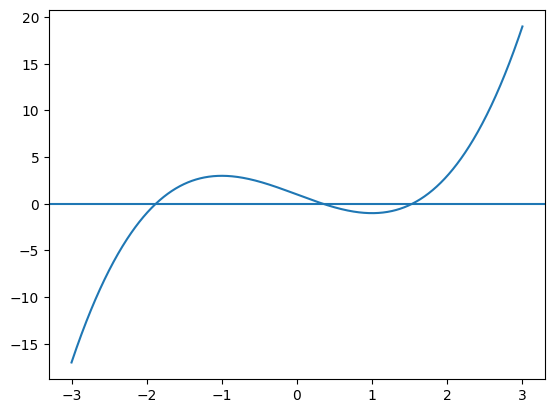

In [ ]:
#scipy를 이용한 비선형 방정식의 해 구하기
import numpy as np
import matplotlib.pyplot as plt

def f(x):
  return x**3-3*x+1

x=np.linspace(-3,3,1000)
plt.axhline(0)
plt.plot(x,f(x))

from scipy.optimize import brentq,newton
brentq(f,-3,0),brentq(f,0,1),brentq(f,1,3)

newton(f,-3),newton(f,0),newton(f,3)

In [ ]:
#scipy.root 이용
from scipy.optimize import root, fsolve
def f(x):
  return [x[1] - 3*x[0]*(x[0]-1)*(x[0]-1),
          0.25*x[0]**2 + x[1]**2-1]
sol=root(f,(0.5,0.5))
print(sol.x)

[0.35737966 0.83778028]


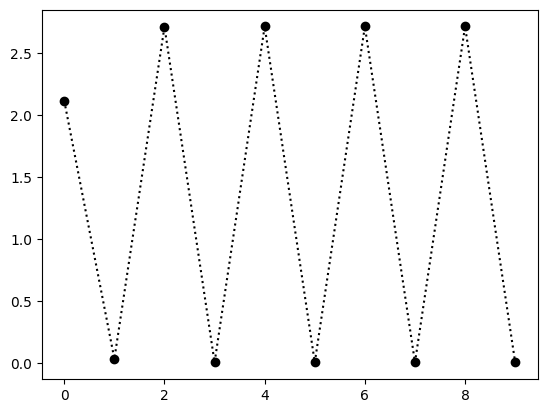

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x=0.5
xs=[]
for i in range(10):
  x=np.exp(1-x**2)
  xs.append(x)
plt.plot(range(10),xs,"o:k")

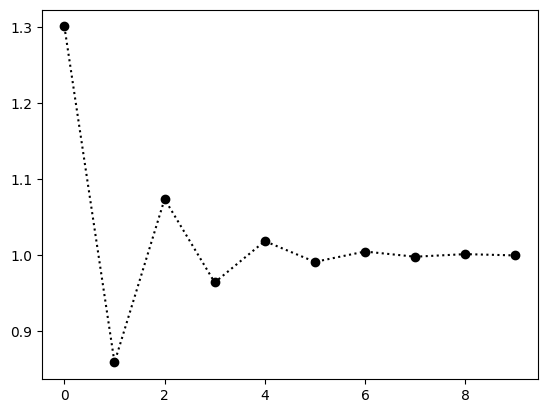

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x=0.5
xs=[]
for i in range(10):
  x=np.sqrt(1-np.log(x))
  xs.append(x)
plt.plot(range(10),xs,"o:k")

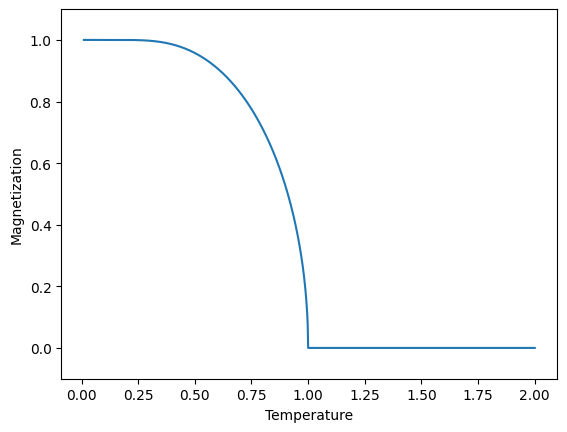

In [ ]:
#강자성체
import numpy as np
import matplotlib.pyplot as plt

Tmax=2.0
points=1000
tol=1e-6

y=[]
temp=np.linspace(0.01,Tmax,points)

for T in temp:
  m1=1.0
  error=1.0
  while error>tol:
    m1,m2=np.tanh(m1/T),m1
    error=abs((m1-m2)/(1-T*np.cosh(m2/T)**2))
  y.append(m1)

plt.plot(temp,y)
plt.ylim(-0.1,1.1)
plt.xlabel("Temperature")
plt.ylabel("Magnetization")
plt.show()



In [6]:
#exercise 6.10(a)
import numpy as np

x=1.0
for k in range(50):
  x=1-np.exp(-2*x)
  print(x)



0.8646647167633873
0.8225966691808597
0.8070247503317746
0.8009201942366403
0.7984747083247583
0.7974866394625985
0.797086049491047
0.796923413762181
0.7968573480008734
0.7968305046795713
0.7968195968986895
0.7968151643557075
0.7968133630966887
0.7968126311118457
0.7968123336514794
0.7968122127708882
0.7968121636479626
0.7968121436855996
0.7968121355733799
0.7968121322767707
0.7968121309371088
0.7968121303927027
0.7968121301714692
0.7968121300815654
0.7968121300450306
0.7968121300301837
0.7968121300241503
0.7968121300216985
0.7968121300207021
0.7968121300202972
0.7968121300201326
0.7968121300200658
0.7968121300200386
0.7968121300200276
0.796812130020023
0.7968121300200213
0.7968121300200206
0.7968121300200203
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202
0.7968121300200202


In [5]:
#exercise 6.10(a)
import numpy as np

y=[]
errors=[]
accuracy=1e-6
x1=1.0
error=1.0

def f(x):
  return 1-np.exp(-2*x)

def df(x):
  return 0.5*np.exp(2*x)

for i in range(30):
  x2=f(x1)
  error=abs((x1-x2)/(1-df(x1)))
  x1=x2
  y.append(x1)
  errors.append(error)
if error<accuracy: # 오차가 정확도보다 작은 경우
    print(y)




[np.float64(0.8646647167633873), np.float64(0.8225966691808597), np.float64(0.8070247503317746), np.float64(0.8009201942366403), np.float64(0.7984747083247583), np.float64(0.7974866394625985), np.float64(0.797086049491047), np.float64(0.796923413762181), np.float64(0.7968573480008734), np.float64(0.7968305046795713), np.float64(0.7968195968986895), np.float64(0.7968151643557075), np.float64(0.7968133630966887), np.float64(0.7968126311118457), np.float64(0.7968123336514794), np.float64(0.7968122127708882), np.float64(0.7968121636479626), np.float64(0.7968121436855996), np.float64(0.7968121355733799), np.float64(0.7968121322767707), np.float64(0.7968121309371088), np.float64(0.7968121303927027), np.float64(0.7968121301714692), np.float64(0.7968121300815654), np.float64(0.7968121300450306), np.float64(0.7968121300301837), np.float64(0.7968121300241503), np.float64(0.7968121300216985), np.float64(0.7968121300207021), np.float64(0.7968121300202972)]


In [ ]:
#이분법(빈의 변위법칙)
import numpy as np

h=6.626e-34
c=3e+8
k=1.380e-23
lamb=502e-9



def f(x):
  return 5*np.exp(-x)+x-5

def binary(f,a,b,accuracy,max_iter):
  if f(a)*f(b)>0:
    print("error")
  else:
    for i in range(max_iter):
      c=(a+b)/2
      if f(a)*f(c)<0:
        b=c
      else:
        a=c
      if abs(a-b)<accuracy:
        return c

d=binary(f,0,7,1e-6,100)
print(d)
print("태양의 온도:",(h*c)/(k*d*lamb))









4.96511447429657
태양의 온도: 5779.105420595558


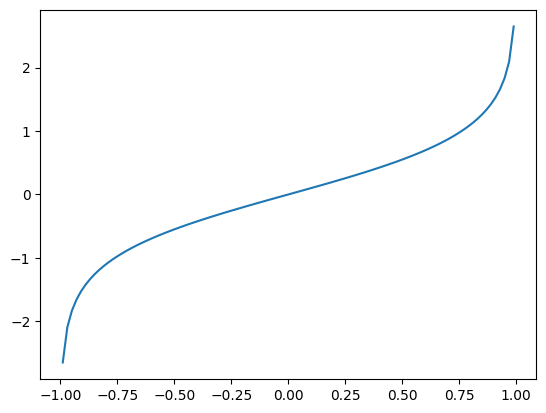

In [ ]:
#뉴턴방법(example 6.4)
import numpy as np
import matplotlib.pyplot as plt

accuracy=1e-12

def arctanh(u):
  x=0.0
  delta=1.0
  while abs(delta)>accuracy:
    delta=(np.tanh(x)-u)*(np.cosh(x)**2)
    x-=delta
  return x

upoints=np.linspace(-0.99,0.99,100)
xpoints=[]

for u in upoints:
  xpoints.append(arctanh(u))
plt.plot(upoints,xpoints)
plt.show()




In [10]:
#exercise 6.15 the loots of a polynomial(b)
import numpy as np
import matplotlib.pyplot as plt

accuracy=1e-10

def f(x):
  return 924*x**6-2772*x**5+3150*x**4-1680*x**3+420*x**2-42*x+1

def df(x):
  return 5544*x**5-13860*x**4+12600*x**3-5040*x**2+840*x-42

def newton(x,tol):
  delta=1.0
  while abs(delta)>tol:
    if df(x)==0:
      print("error")
    else:
      delta=(f(x)/df(x))
      x-=delta
  return x

a=newton(0.2,accuracy)
b=newton(0.4,accuracy)
c=newton(0.6,accuracy)
d=newton(0.8,accuracy)
e=newton(1,accuracy)
g=newton(0.0,accuracy)

print(a)
print(b)
print(c)
print(d)
print(e)
print(g)






0.16939530676686765
0.3806904069584
0.619309593041593
0.8306046932331476
0.9662347571016031
0.03376524289842398


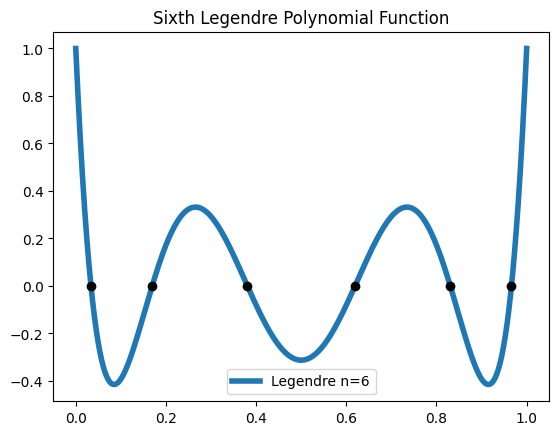

In [9]:
#exercise 6.15 the loots of a polynomial(a) 6차 르장드르 다항식의 해 찾기
import numpy as np
import matplotlib.pyplot as plt

def f(x): #르장드르 방정식 표현
  return 924*x**6-2772*x**5+3150*x**4-1680*x**3+420*x**2-42*x+1

x=np.linspace(0,1,1000)

plt.plot(x,f(x),lw=4,label='Legendre n=6') #그래프 (위에 해 설정)
plt.plot(g,f(g),'ko')
plt.plot(a,f(a),'ko')
plt.plot(b,f(b),'ko')
plt.plot(c,f(c),'ko')
plt.plot(d,f(d),'ko')
plt.plot(e,f(e),'ko')
plt.title("Sixth Legendre Polynomial Function")
plt.legend()
plt.show()


In [ ]:
#분할법

def secant_method(f,x0,x1,tol,max_iter):
  for i in range(max_iter):
    f0=f(x0)
    f1=f(x1)
    x2 = x1 - f1 * ((x1 - x0) / (f1 - f0))
    if abs(f(x2))<tol:
      print(f"{i+1}번 반복한 순간 찾은해:",x2)
      return x2
    x0=x1
    x1=x2
  print("지정된 반복횟수 내에 해 찾기 실패")
  return x1


func=lambda x: x**2-5
root = secant_method(func,2.0,3.0,1e-7,100)

print(f"계산된 정답: {root}")

5번 반복한 순간 찾은해: 2.2360679774992964
계산된 정답: 2.2360679774992964


In [ ]:
#분할법(문제 6.16)

from scipy.optimize import root_scalar,newton

G=6.674e-11
M=5.974e+24
m=7.348e+22
R=3.844e+8
w=2.662e-6

def lagrange(r):
  return G*m*(R-r)**2-(w**2)*(r**3)*(R-r)**2-G*m*(r**2)

# 'scipy.optimize.root_scalar'를 'root_scalar'로 변경하고, 'lagrange(r)'을 'lagrange'로 변경
d=root_scalar(lagrange,method='secant',x0=1.922e+8,x1=3.075e+8)
e=newton(lagrange,x0=1.922e+8,tol=1.48e-08, maxiter=50)
print(d)
print(e)

      converged: True
           flag: converged
 function_calls: 15
     iterations: 14
           root: 85937803.60238327
         method: secant
85937803.60238327


In [ ]:
#Problem 6.6 solution 2
import numpy as np

G=6.674e-11
M=5.974e+24
m=7.348e+22
R=3.844e+8
w=2.662e-6

def lagrange(r): #라그랑주 식 변환
  return G*m*(R-r)**2-(w**2)*(r**3)*(R-r)**2-G*m*(r**2)
print(lagrange(1.922e+8))
print(lagrange(3.075e+8))

def secant(f,x0,x1,tol,max_iter):
  for i in range(max_iter):
    f0=f(x0)
    f1=f(x1)
    if f1-f0==0:
      x2=x1-f1*(x1-x0)
    else:
      x2=x1-f1*((x1-x0)/(f1-f0))
    if abs(f(x2))<tol:
      print(f"라그랑주 점:",x2)
      return x2
    x0=x1
    x1=x2
  return x1

L=secant(lagrange,1.922e+8,3.075e+8,1e-6,100)
print(L)


-1.8585875298713537e+30
-1.6531483835251905e+30
85937803.60238327
